In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# 1. Load MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# 2. Resizing & Reshaping for CNN (28x28x1) / إعادة تشكيل الأبعاد لتناسب شبكة الـ CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 3. Normalization (Scale pixels between 0 and 1) / تطبيع قيم البكسلات بين 0 و 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# 4. One-hot encode the labels
y_train_encoded = to_categorical(y_train, 10)
y_test_encoded = to_categorical(y_test, 10)

print(f"Train shape / حجم بيانات التدريب: {X_train.shape}")
print(f"Test shape / حجم بيانات الاختبار: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape / حجم بيانات التدريب: (60000, 28, 28, 1)
Test shape / حجم بيانات الاختبار: (10000, 28, 28, 1)


In [2]:
# Build CNN Model 1 / بناء نموذج الـ CNN الأول
model_1 = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)), # Convolutional Layer 1
    MaxPooling2D(pool_size=(2, 2)),                                            # Max Pooling 1
    Conv2D(64, kernel_size=(3, 3), activation='relu'),                         # Convolutional Layer 2
    MaxPooling2D(pool_size=(2, 2)),                                            # Max Pooling 2
    Flatten(),                                                                 # Flattening
    Dense(128, activation='relu'),                                             # Hidden Dense Layer
    Dropout(0.2),                                                              # Enhancement: Dropout layer
    Dense(10, activation='softmax')                                            # Output Layer
])

# Experiment 1: Using Adam Optimizer with LR=0.001 / التجربة 1: استخدام محسن Adam
optimizer_1 = tf.keras.optimizers.Adam(learning_rate=0.001)

model_1.compile(optimizer=optimizer_1, loss='categorical_crossentropy', metrics=['accuracy'])

print("--- Starting Experiment 1 (Adam) / بدء تدريب التجربة الأولى ---")
# Train with 20% validation split / التدريب مع مراقبة دقة وفقد التحقق
history_1 = model_1.fit(X_train, y_train_encoded, epochs=5, batch_size=64, validation_split=0.2, verbose=1)

--- Starting Experiment 1 (Adam) / بدء تدريب التجربة الأولى ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 57ms/step - accuracy: 0.9372 - loss: 0.2032 - val_accuracy: 0.9832 - val_loss: 0.0580
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9804 - loss: 0.0638 - val_accuracy: 0.9846 - val_loss: 0.0525
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9865 - loss: 0.0438 - val_accuracy: 0.9866 - val_loss: 0.0481
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 81s 55ms/step - accuracy: 0.9890 - loss: 0.0352 - val_accuracy: 0.9902 - val_loss: 0.0383
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9912 - loss: 0.0274 - val_accuracy: 0.9905 - val_loss: 0.0360


In [3]:
# Build CNN Model 2 (Same Architecture) / بناء النموذج الثاني بنفس البنية تماماً
model_2 = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

# Experiment 2: Using SGD Optimizer with LR=0.01 / التجربة 2: تغيير المحسن إلى SGD
optimizer_2 = tf.keras.optimizers.SGD(learning_rate=0.01)

model_2.compile(optimizer=optimizer_2, loss='categorical_crossentropy', metrics=['accuracy'])

print("\n--- Starting Experiment 2 (SGD) / بدء تدريب التجربة الثانية ---")
history_2 = model_2.fit(X_train, y_train_encoded, epochs=5, batch_size=64, validation_split=0.2, verbose=1)


--- Starting Experiment 2 (SGD) / بدء تدريب التجربة الثانية ---
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.7209 - loss: 0.9515 - val_accuracy: 0.9177 - val_loss: 0.2806
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9085 - loss: 0.3005 - val_accuracy: 0.9454 - val_loss: 0.1884
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9344 - loss: 0.2160 - val_accuracy: 0.9588 - val_loss: 0.1453
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9490 - loss: 0.1697 - val_accuracy: 0.9665 - val_loss: 0.1194
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.9564 - loss: 0.1434 - val_accuracy: 0.9693 - val_loss: 0.1049


In [4]:
# Evaluate Experiment 1 / تقييم التجربة الأولى
loss_1, acc_1 = model_1.evaluate(X_test, y_test_encoded, verbose=0)

# Evaluate Experiment 2 / تقييم التجربة الثانية
loss_2, acc_2 = model_2.evaluate(X_test, y_test_encoded, verbose=0)

print("\n================ Structured Comparison Table / جدول النتائج والمقارنة ================")
print(f"Model 1 (Adam Optimizer) -> Accuracy: {acc_1*100:.2f}%, Loss: {loss_1:.4f}")
print(f"Model 2 (SGD Optimizer)  -> Accuracy: {acc_2*100:.2f}%, Loss: {loss_2:.4f}")
print("======================================================================================")


================ Structured Comparison Table / جدول النتائج والمقارنة ================
Model 1 (Adam Optimizer) -> Accuracy: 99.18%, Loss: 0.0263
Model 2 (SGD Optimizer)  -> Accuracy: 97.15%, Loss: 0.0952


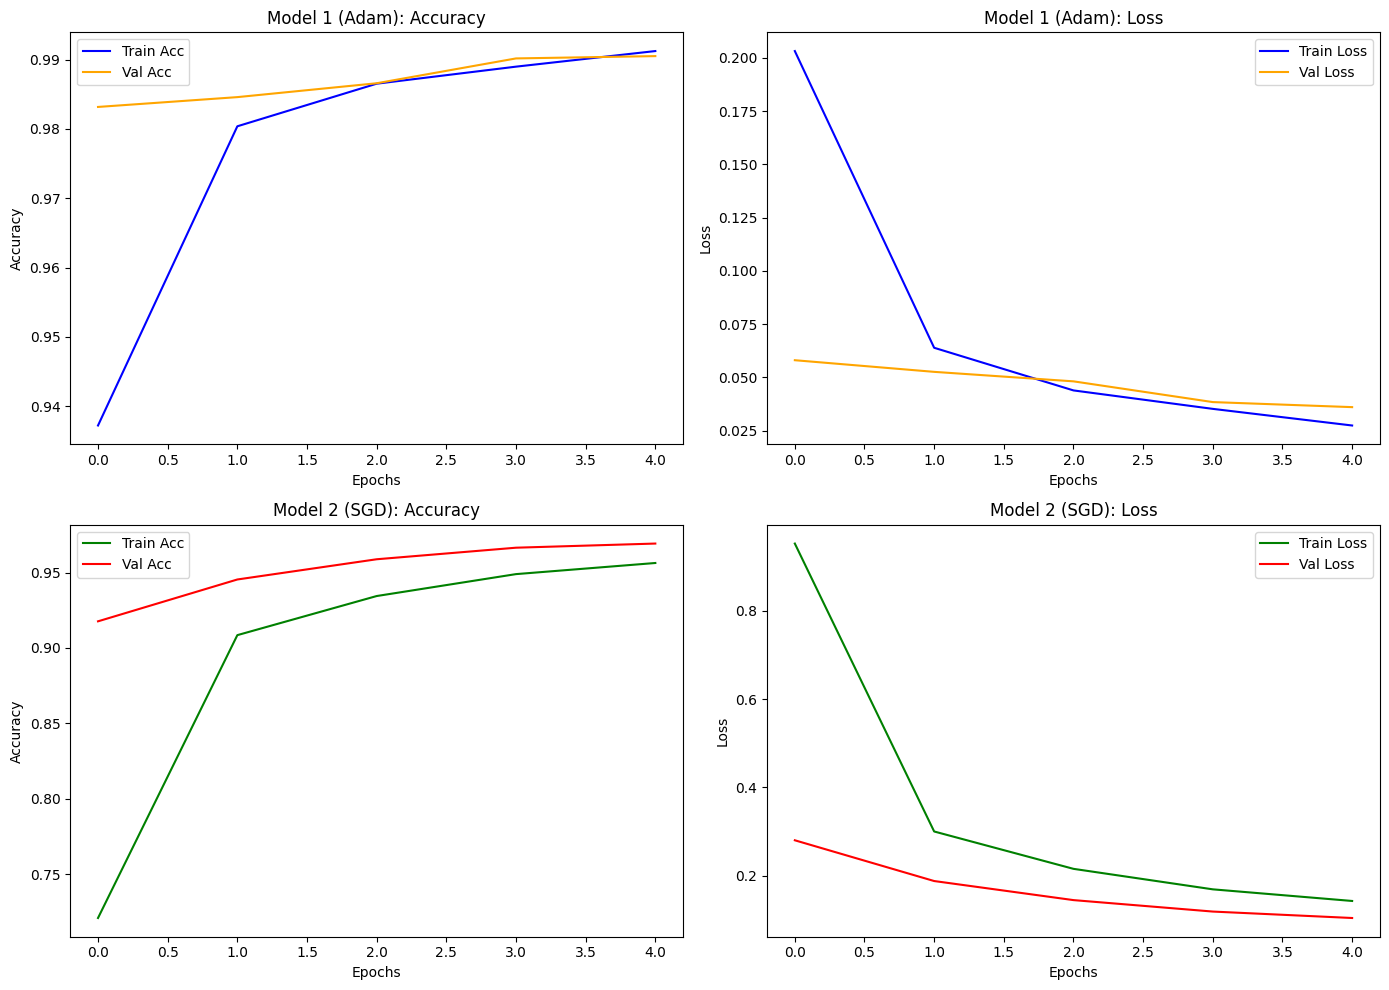

In [5]:
plt.figure(figsize=(14, 10))

# 1. Model 1: Accuracy Curves / دقة النموذج الأول
plt.subplot(2, 2, 1)
plt.plot(history_1.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history_1.history['val_accuracy'], label='Val Acc', color='orange')
plt.title('Model 1 (Adam): Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. Model 1: Loss Curves / فقد النموذج الأول
plt.subplot(2, 2, 2)
plt.plot(history_1.history['loss'], label='Train Loss', color='blue')
plt.plot(history_1.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model 1 (Adam): Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 3. Model 2: Accuracy Curves / دقة النموذج الثاني
plt.subplot(2, 2, 3)
plt.plot(history_2.history['accuracy'], label='Train Acc', color='green')
plt.plot(history_2.history['val_accuracy'], label='Val Acc', color='red')
plt.title('Model 2 (SGD): Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 4. Model 2: Loss Curves / فقد النموذج الثاني
plt.subplot(2, 2, 4)
plt.plot(history_2.history['loss'], label='Train Loss', color='green')
plt.plot(history_2.history['val_loss'], label='Val Loss', color='red')
plt.title('Model 2 (SGD): Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()